## Add sub-states and downstream

In [2]:
import scanpy as sc
#from scanpy.plotting._tools import plot_scatter
sc.set_figure_params(vector_friendly=False, fontsize=18)
import os, sys, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter
import seaborn as sns

import anndata
import os
import h5py
import warnings

from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

warnings.filterwarnings("ignore")

from typing import Tuple, Union, List, Dict, Callable

from adjustText import adjust_text
import matplotlib
%matplotlib inline

In [3]:
matplotlib.rcParams['pdf.fonttype'] = 42

In [4]:
home      = "/Users/shayat/Documents/Aachen/projects/cul3_turgay/"
datahome  = home+ "data/"
resulthome= home+ "results/"
dehome    = resulthome+"DE/"

In [5]:
filename = 'pt_ipt_populations.h5ad'

## READ

In [6]:
adata = sc.read_h5ad(resulthome+ filename)

In [7]:
adata

AnnData object with n_obs × n_vars = 33701 × 15429
    obs: 'Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', 'Core.Matrisome.Expression.Score', 'Patient ID', 'mypatients', 'myconditions', 'sex', 'Sex', 'Age [years]', 'Serum creatinine [mg/dL]', 'eGFR (mL/min/1.73m2)', 'Interstitial fibrosis [%]', 'Tubular atrophy [%]', 'ischemia time in minutes', 'diabetes', 'Hyper-tension', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'mycelltypes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sizeFactor', 'ident', 'leiden1.1', 'batch', 'leiden0.1', 'leiden0.3', 'leiden0.5', 'leiden0.7', 'leiden0.9', 'leiden1.3', 'leiden1.5', 'leiden1.7'
    var: 'gene_ids-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0'
    uns: 'rank_genes_groups0.1', 'rank_genes_groups0.3', 'rank_genes_groups0.5', 'rank_genes_groups0.7', 'rank_genes_groups0.9', 'rank_genes_groups1.1', 'rank_genes_groups1.3', 'rank_genes_groups1.

In [8]:
#adata = adata.raw.to_adata()

In [9]:
len(Counter(adata.obs["mypatients"]))

19

In [10]:
res = 0.9

In [11]:
# add treatment status
ckd_samples     = set(['ckd',  'benigne nephrosclerosis'])
control_samples = set(['healthy', 'Normal kidney'])

def get_treatment(s):
    if s in ckd_samples:
        return 'ckd'
    elif s in control_samples:
        return 'healthy'
    else:
        raise ValueError(f'sample {s} not in definitions')

adata.obs['myconditions_combined'] = adata.obs['myconditions'].apply(get_treatment).astype('category')

In [12]:
# add treatment status
iz_samples      = set(['0', '1', '3', '5'])
control_samples = set(['2', '4', '6', '7', '8'])

def get_treatment(s):
    if s in iz_samples:
        return 'CUL3 Negative'
    elif s in control_samples:
        return 'CUL3 Positive'
    else:
        raise ValueError(f'sample {s} not in definitions')

#adata.obs['CUL3_status'] \
#= adata.obs['leiden' + str(res)].apply(get_treatment).astype('category')

In [13]:
#  Custer naming

cluster_names = {
"0":"0: PT",
"1":"1: PT",
"2":"2: PT/likely stressed PT_tL",
"3":"3: PT",
"4":"4: late injured PT_tL_S1",
"5":"5: PT",
"6":"6: late injured_EC_tL_TAL",
"7":"7: injured PT",
"8":"8: Injured PT"
}

adata.obs['leiden' + str(res)] = adata.obs['leiden' + str(res)].apply(lambda s: cluster_names[s])

In [14]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,batch,leiden0.1,leiden0.3,leiden0.5,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,0,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,0,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,0,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,0,0,1,1,3,2: PT/likely stressed PT_tL,3,5,6,healthy
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,0,0,1,1,3,2: PT/likely stressed PT_tL,3,5,6,healthy


In [15]:
adata.obs[['Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', "leiden0.9"]].drop_duplicates()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,leiden0.9
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,6: late injured_EC_tL_TAL
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,2: PT/likely stressed PT_tL
29912-0,Epithelial,Proximal Tubule,Proximal Tubule,4: late injured PT_tL_S1
30045-0,Epithelial,Injured Tubule,Injured Proximal tubule,4: late injured PT_tL_S1
30373-0,Epithelial,Proximal Tubule,Proximal Tubule,5: PT
...,...,...,...,...
cell3447-1,Epithelial,PT,S3 3,7: injured PT
cell3448-1,Epithelial,PT,S1/2 3,7: injured PT
cell3661-1,Epithelial,PT,S3 2,8: Injured PT
cell3869-1,Epithelial,PT,S1/2 1,5: PT


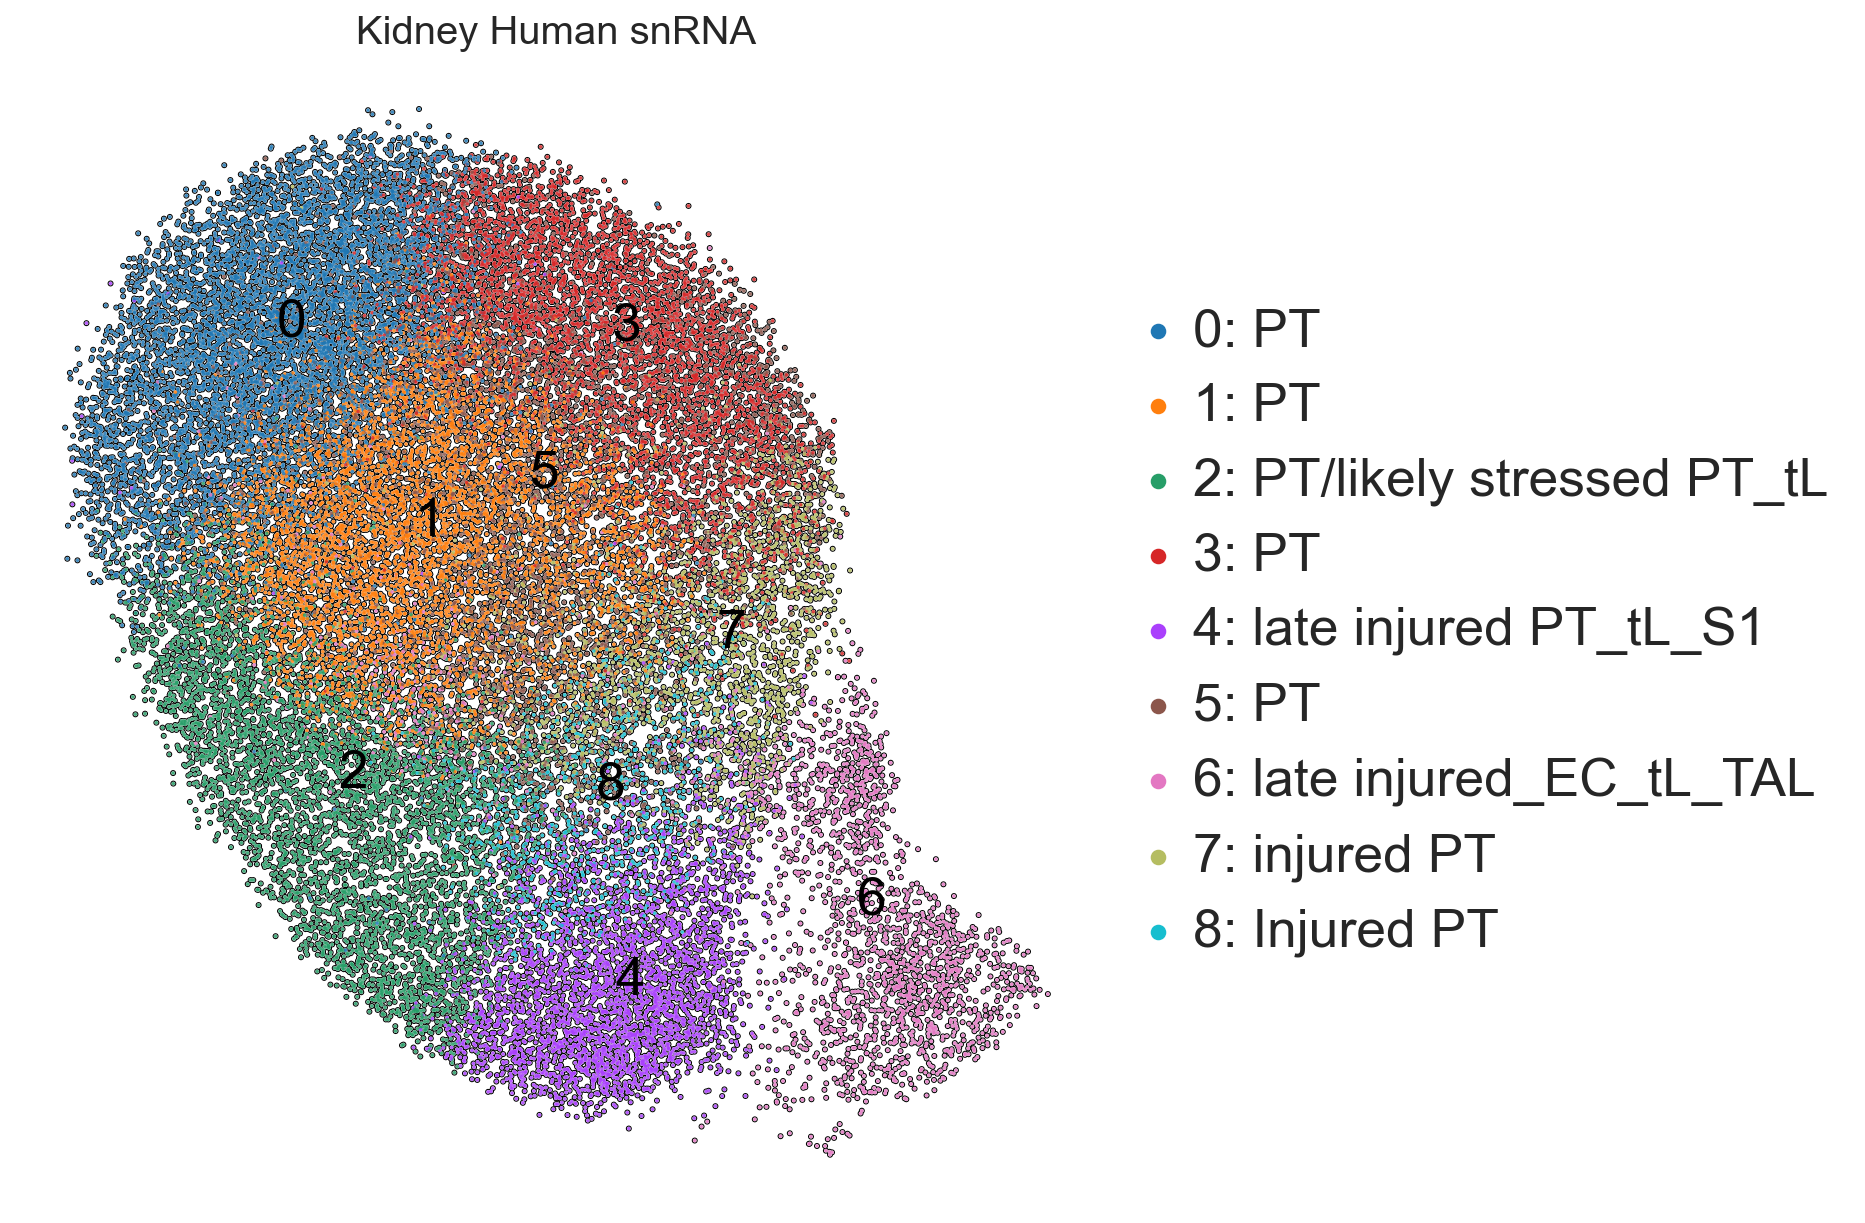

In [16]:
# show clustering with numbers

plt.figure(figsize=(12, 8))
sc.pl.embedding(adata, add_outline=True, basis='umap', color='leiden0.9',\
                ax=plt.gca(), alpha=0.85, size=10, legend_fontsize=24,legend_fontoutline=0,\
                frameon=False, show=False)

df            = pd.DataFrame(adata.obsm['X_umap'])
df['cluster'] = adata.obs['leiden0.9'].values
mean_pos      = df.groupby('cluster').median()

for c in mean_pos.index:    
    plt.gca().text(mean_pos.loc[c][0], mean_pos.loc[c][1], c.split(':')[0], 
                   fontsize=24, color='black')

plt.title('Kidney Human snRNA')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

plt.tight_layout()
#plt.savefig(resulthome+'MI_Human_snRNA.pdf', bbox_inches='tight')
#plt.show()

In [30]:
#sc.set_figure_params(fontsize=14)
#sc.pl.embedding(adata, basis='UMAP_HARMONY', color=gene_list, color_map='Oranges', size=30, ncols=2)

In [31]:
Counter(adata.obs["leiden0.9"])

Counter({'0: PT': 6793,
         '1: PT': 5802,
         '2: PT/likely stressed PT_tL': 4758,
         '3: PT': 4417,
         '4: late injured PT_tL_S1': 3490,
         '5: PT': 3246,
         '6: late injured_EC_tL_TAL': 2279,
         '7: injured PT': 1895,
         '8: Injured PT': 1021})

In [32]:
gene_list = ['CUL3', 'VCAM1']

In [33]:
adata.obs['barcode'] = adata.obs.index

In [34]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,leiden0.1,leiden0.3,leiden0.5,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined,barcode
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29815-0
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29816-0
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,1,3,5,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29817-0
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,0,1,1,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29818-0
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,0,1,1,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29820-0


In [35]:
def get_gene_score(s):
    if s in gene_pos_list:
        return 'g_pos'
    elif s not in gene_pos_list:
        return 'g_neg'
    else:
        raise ValueError(f'sample {s} not in definitions')

In [36]:
cluster_id = "leiden0.9"

In [37]:
frames = []

for genename in gene_list:
    a      = np.asarray(adata[:,genename].X.todense())
    adata1 = adata[a> 0].copy()#[:,'NEAT1'].obs.head()

    gene_pos_list = adata1.obs.index.values.tolist()

    adata.obs[genename+'_Status'] = adata.obs['barcode'].apply(get_gene_score).astype('category')
    
    adata.write(resulthome + filename[:-5] + '_' + genename + '.h5ad')
    print(adata.shape)
    
    df = pd.crosstab(adata.obs[cluster_id], adata.obs[genename+'_Status'])
    df['total']     = df.sum(axis=1)
    df['g_percent'] = np.round(100.0*df['g_pos']/df['total'],4)
    df['g_name'] = genename
    print(df.head())
    frames.append(df)

(33701, 15429)
CUL3_Status                  g_neg  g_pos  total  g_percent g_name
leiden0.9                                                         
0: PT                         6493    300   6793     4.4163   CUL3
1: PT                         5463    339   5802     5.8428   CUL3
2: PT/likely stressed PT_tL   4252    506   4758    10.6347   CUL3
3: PT                         4173    244   4417     5.5241   CUL3
4: late injured PT_tL_S1      2472   1018   3490    29.1691   CUL3
(33701, 15429)
VCAM1_Status                 g_neg  g_pos  total  g_percent g_name
leiden0.9                                                         
0: PT                         6646    147   6793     2.1640  VCAM1
1: PT                         5702    100   5802     1.7235  VCAM1
2: PT/likely stressed PT_tL   4458    300   4758     6.3052  VCAM1
3: PT                         4332     85   4417     1.9244  VCAM1
4: late injured PT_tL_S1      2960    530   3490    15.1862  VCAM1


In [72]:
Counter(adata.obs['CUL3_Status'])

Counter({'g_neg': 30091, 'g_pos': 3610})

In [39]:
frames = []

for genename in gene_list:
    a      = np.asarray(adata[:,genename].X.todense())
    adata1 = adata[a> 0].copy()#[:,'NEAT1'].obs.head()

    gene_pos_list = adata1.obs.index.values.tolist()

    adata.obs['g_Status'] = adata.obs['barcode'].apply(get_gene_score).astype('category')
    
    adata.write(resulthome + filename[:-5] + '_' + genename + '.h5ad')
    print(adata.shape)
    
    df = pd.crosstab(adata.obs[cluster_id], adata.obs['g_Status'])
    df['total']     = df.sum(axis=1)
    df['g_percent'] = np.round(100.0*df['g_pos']/df['total'],4)
    df['g_name'] = genename
    print(df.head())
    frames.append(df)

(33701, 15429)
g_Status                     g_neg  g_pos  total  g_percent g_name
leiden0.9                                                         
0: PT                         6493    300   6793     4.4163   CUL3
1: PT                         5463    339   5802     5.8428   CUL3
2: PT/likely stressed PT_tL   4252    506   4758    10.6347   CUL3
3: PT                         4173    244   4417     5.5241   CUL3
4: late injured PT_tL_S1      2472   1018   3490    29.1691   CUL3
(33701, 15429)
g_Status                     g_neg  g_pos  total  g_percent g_name
leiden0.9                                                         
0: PT                         6646    147   6793     2.1640  VCAM1
1: PT                         5702    100   5802     1.7235  VCAM1
2: PT/likely stressed PT_tL   4458    300   4758     6.3052  VCAM1
3: PT                         4332     85   4417     1.9244  VCAM1
4: late injured PT_tL_S1      2960    530   3490    15.1862  VCAM1


In [40]:
pdf = pd.concat(frames)

In [41]:
pdf.reset_index(inplace=True)

In [42]:
pdf

g_Status,leiden0.9,g_neg,g_pos,total,g_percent,g_name
0,0: PT,6493,300,6793,4.4163,CUL3
1,1: PT,5463,339,5802,5.8428,CUL3
2,2: PT/likely stressed PT_tL,4252,506,4758,10.6347,CUL3
3,3: PT,4173,244,4417,5.5241,CUL3
4,4: late injured PT_tL_S1,2472,1018,3490,29.1691,CUL3
5,5: PT,3020,226,3246,6.9624,CUL3
6,6: late injured_EC_tL_TAL,1828,451,2279,19.7894,CUL3
7,7: injured PT,1644,251,1895,13.2454,CUL3
8,8: Injured PT,746,275,1021,26.9344,CUL3
9,0: PT,6646,147,6793,2.1640,VCAM1


In [43]:
hdf = pdf[[cluster_id, 'g_name', 'g_percent']].pivot(columns='g_name', index=cluster_id, values='g_percent')

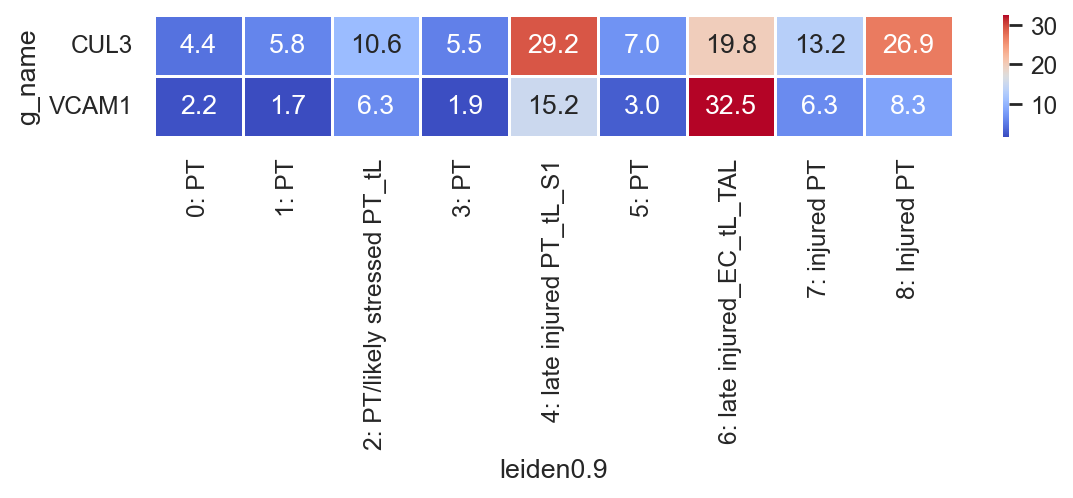

In [44]:
sns.set_theme()

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(8, 1))
svm=sns.heatmap(hdf.T, annot=True, fmt=".1f", linewidths=.5, ax=ax, cmap="coolwarm")
figure = svm.get_figure()

figure.savefig(resulthome+'marker_percentage.pdf', dpi=400,bbox_inches='tight')

In [45]:
adata

AnnData object with n_obs × n_vars = 33701 × 15429
    obs: 'Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', 'Core.Matrisome.Expression.Score', 'Patient ID', 'mypatients', 'myconditions', 'sex', 'Sex', 'Age [years]', 'Serum creatinine [mg/dL]', 'eGFR (mL/min/1.73m2)', 'Interstitial fibrosis [%]', 'Tubular atrophy [%]', 'ischemia time in minutes', 'diabetes', 'Hyper-tension', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'mycelltypes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sizeFactor', 'ident', 'leiden1.1', 'batch', 'leiden0.1', 'leiden0.3', 'leiden0.5', 'leiden0.7', 'leiden0.9', 'leiden1.3', 'leiden1.5', 'leiden1.7', 'myconditions_combined', 'barcode', 'CUL3_Status', 'VCAM1_Status', 'g_Status'
    var: 'gene_ids-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0'
    uns: 'rank_genes_groups0.1', 'rank_genes_groups0.3', 'rank_genes_groups0.5', 'rank_genes_groups0.7', 'rank_genes_g

In [46]:
####

<Axes: title={'center': 'CUL3_Status'}, xlabel='UMAP1', ylabel='UMAP2'>

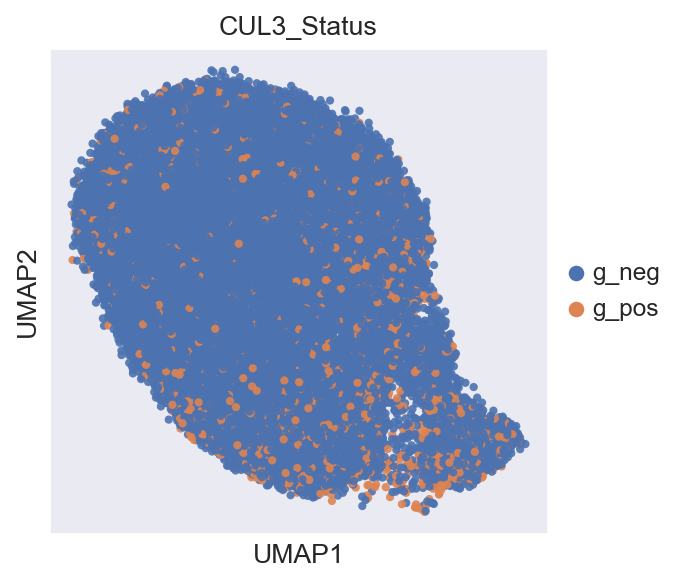

In [47]:
sc.pl.embedding(adata, basis='umap', color='CUL3_Status', ax=plt.gca(), show=False, alpha=0.9, size=55)

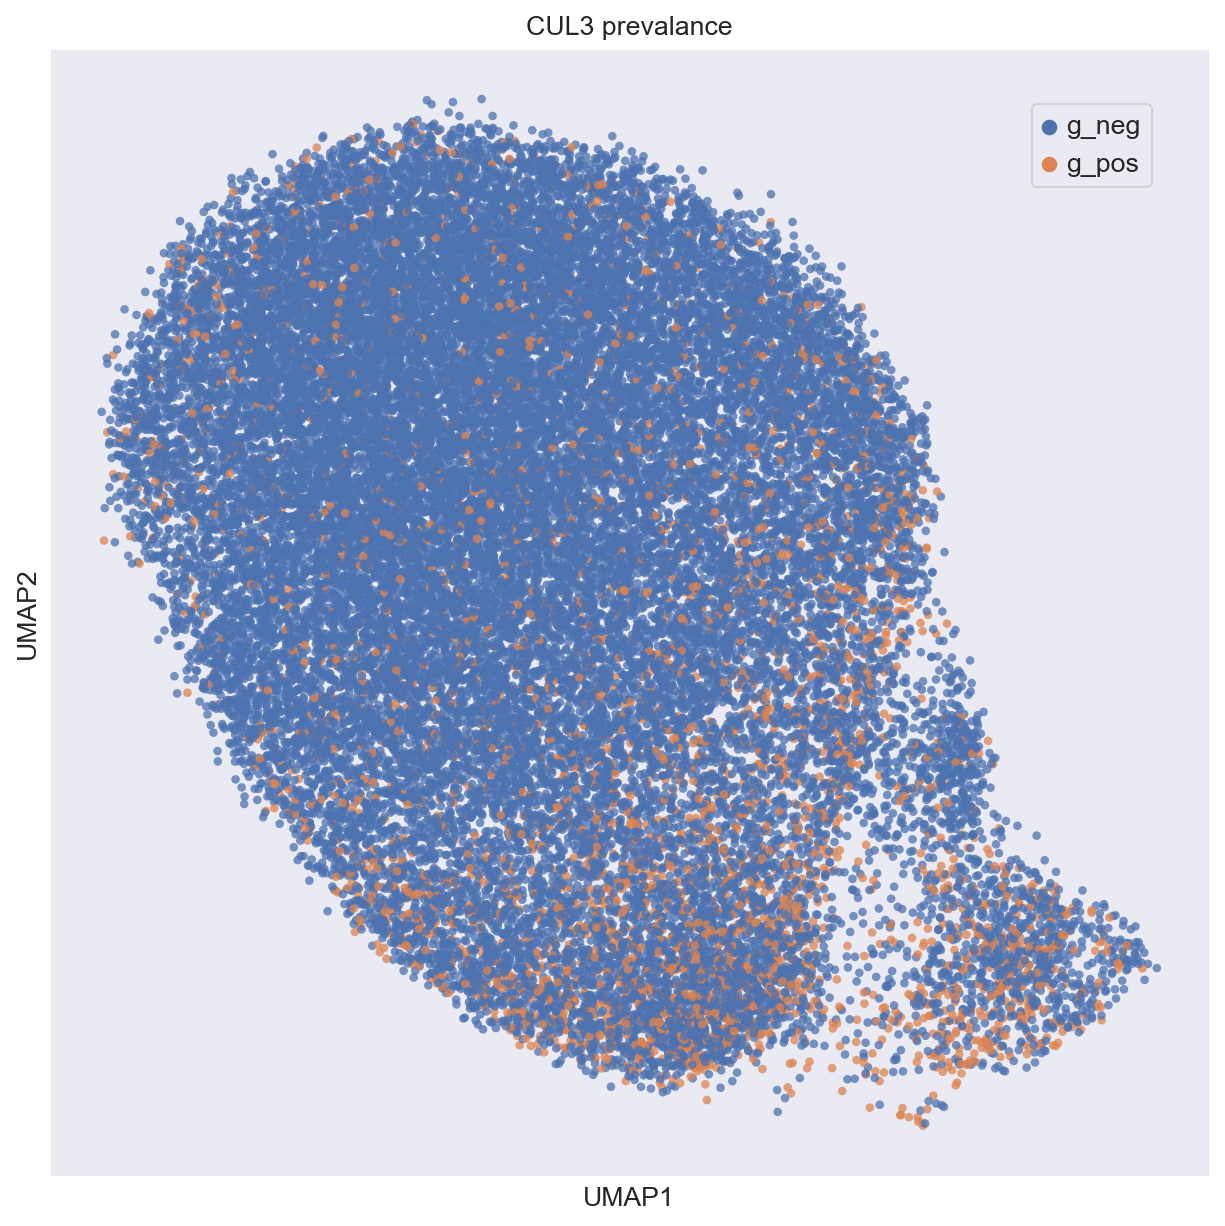

In [62]:
# check out how it looks by tissue
plt.figure(figsize=(8, 8))

#sc.pl.embedding(adata, basis='X_umap', color='cell_type_original', ax=plt.gca(), size=10, alpha=0.05, show=False)
sc.pl.embedding(adata, basis='umap', color='CUL3_Status', ax=plt.gca(), size=60, alpha=0.75, show=False)
plt.title('CUL3 prevalance')
#plt.xlabel('UMAP 1')
#plt.ylabel('UMAP 2')
#plt.show()
#plt.legend(bbox_to_anchor=(0.1, 0.8), loc='upper center', ncol=2, borderaxespad=0, fontsize=12)
plt.legend(bbox_to_anchor=(0.95, 0.95), ncol=1, borderaxespad=0, fontsize=12)

plt.tight_layout()
plt.savefig('Kidney_Human_overlapumap.png', bbox_inches='tight')

In [49]:
#del adata.obs['CUL3_status']#.drop_duplicates()

In [50]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined,barcode,CUL3_Status,VCAM1_Status,g_Status
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29815-0,g_pos,g_pos,g_pos
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29816-0,g_neg,g_pos,g_pos
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29817-0,g_pos,g_pos,g_pos
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29818-0,g_neg,g_neg,g_neg
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29820-0,g_neg,g_pos,g_pos


# Plot genes

In [51]:
# make a copy
tmp_copy_adata = adata.copy()

sc.pp.normalize_per_cell(tmp_copy_adata, counts_per_cell_after=1e4)
sc.pp.log1p(tmp_copy_adata)

In [52]:
sc.pp.scale(tmp_copy_adata, max_value=5)

In [53]:
mycells = tmp_copy_adata.obs['leiden0.9'].drop_duplicates().values.tolist()

In [54]:
genelist = ['CUL3', 'VCAM1']

6: late injured_EC_tL_TAL


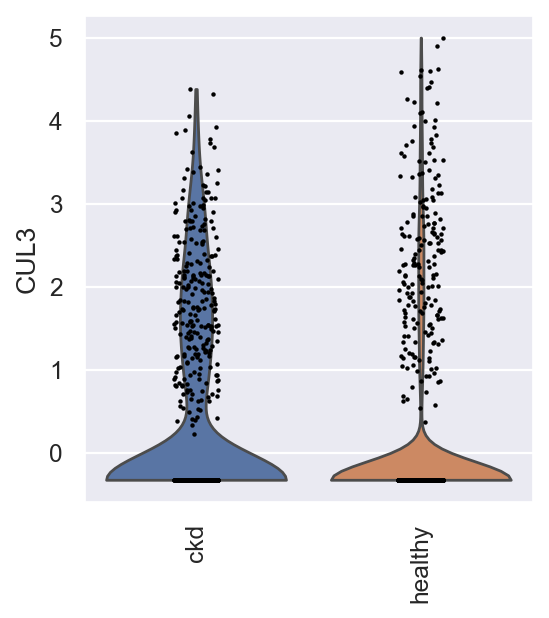

2: PT/likely stressed PT_tL


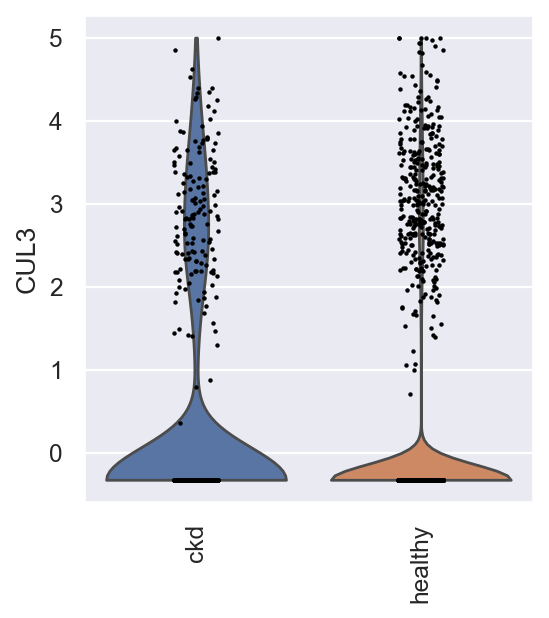

4: late injured PT_tL_S1


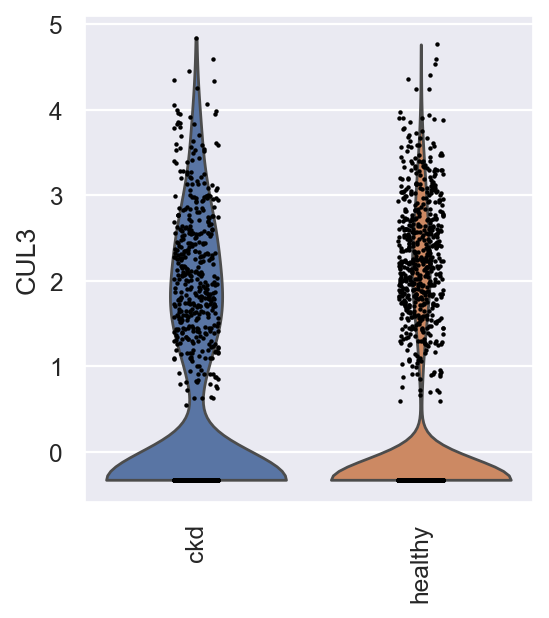

5: PT


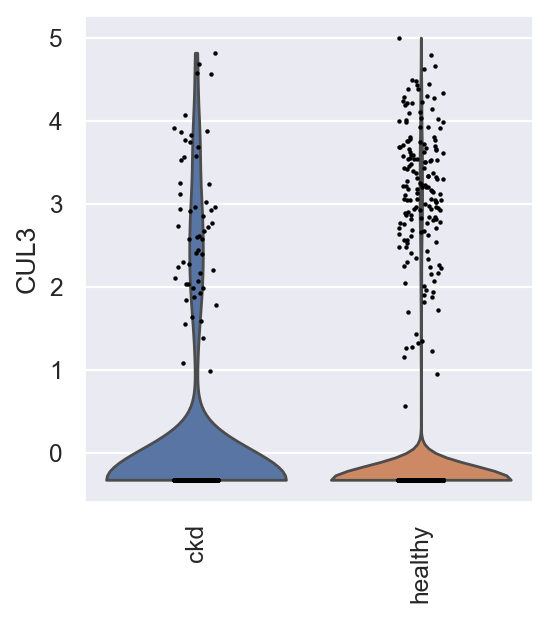

8: Injured PT


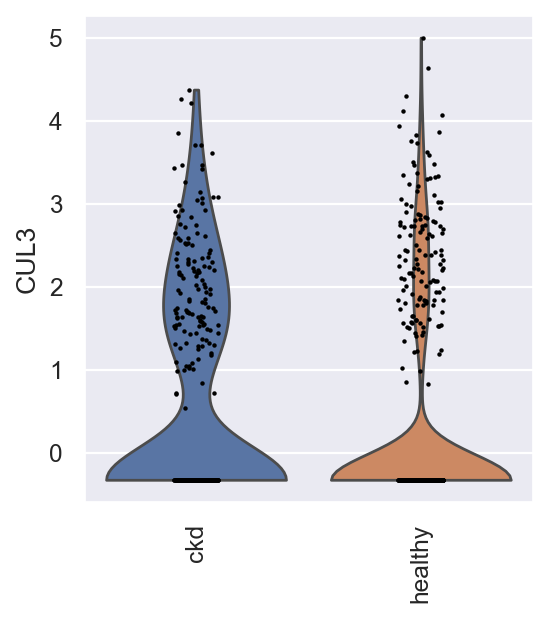

7: injured PT


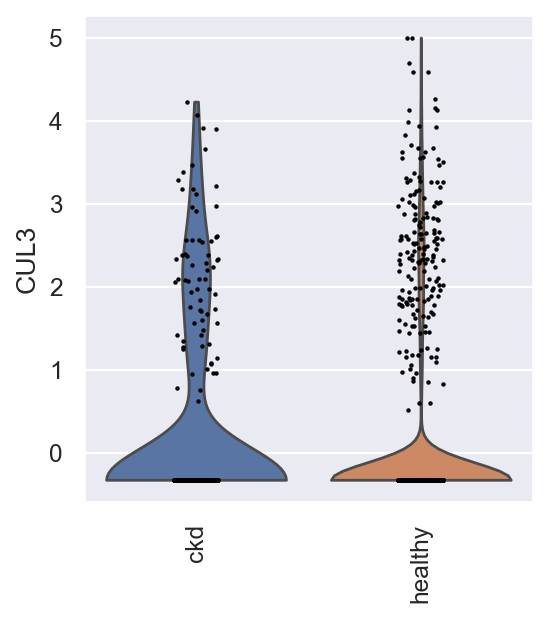

0: PT


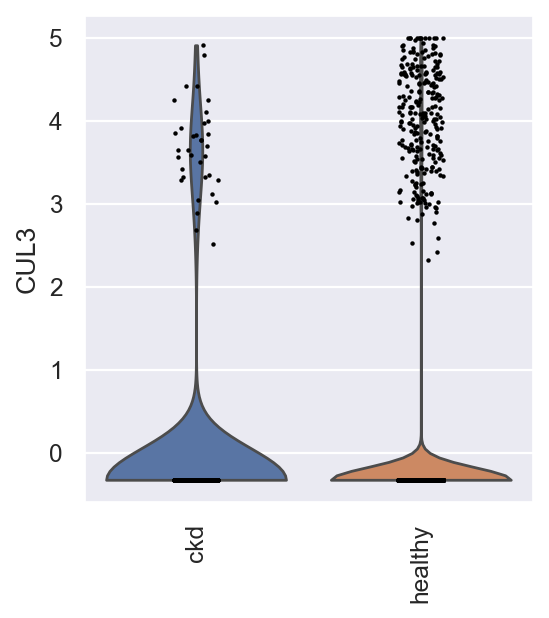

1: PT


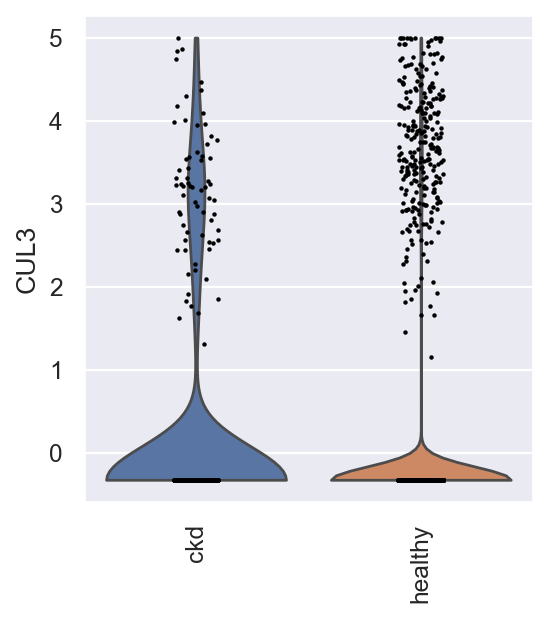

3: PT


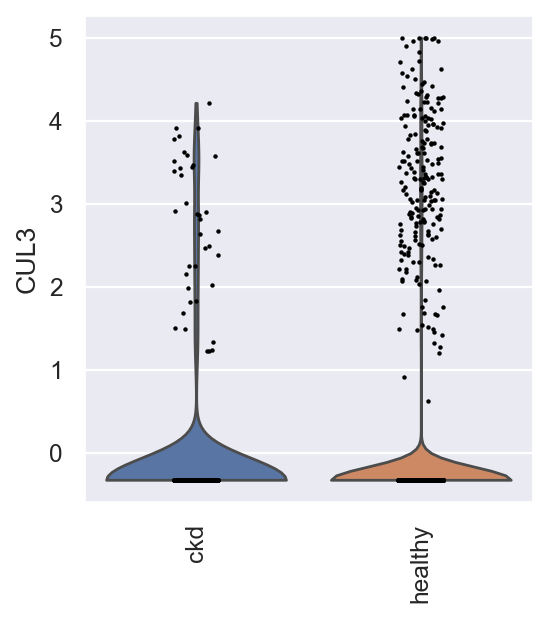

In [54]:
for mycell in mycells:
    print(mycell)
    sc.pl.violin(tmp_copy_adata[tmp_copy_adata.obs['leiden0.9']==mycell],\
                 
                 keys=['CUL3'], groupby='myconditions_combined',\
                 rotation=90, size=2, show=True, use_raw=False)
    
    #plt.savefig(resulthome +'select_genes_umaps_lognorm.pdf', bbox_inches='tight')

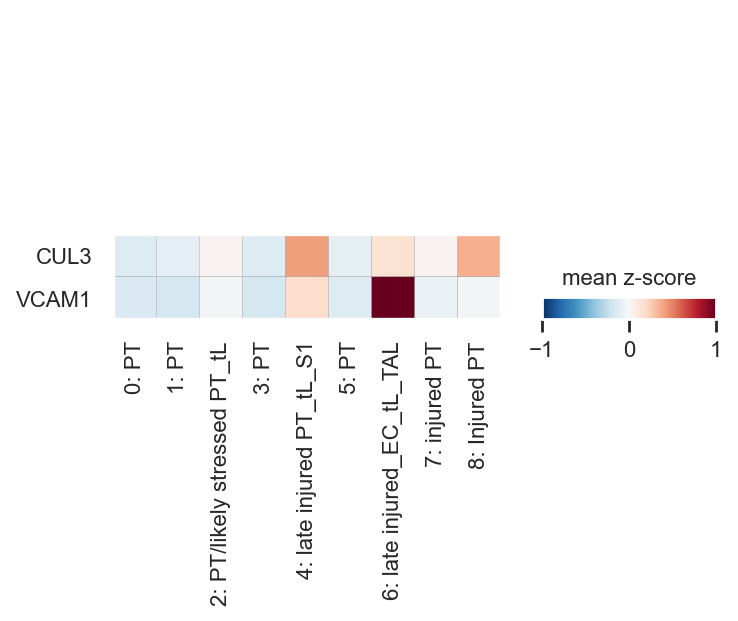

In [55]:
sc.pl.matrixplot(tmp_copy_adata, genelist, 'leiden0.9', dendrogram=False,
                 colorbar_title='mean z-score', #layer='scaledata', 
                 vmin=-1, vmax=1, 
                 cmap='RdBu_r', swap_axes=True)

In [56]:
adata

AnnData object with n_obs × n_vars = 33701 × 15429
    obs: 'Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', 'Core.Matrisome.Expression.Score', 'Patient ID', 'mypatients', 'myconditions', 'sex', 'Sex', 'Age [years]', 'Serum creatinine [mg/dL]', 'eGFR (mL/min/1.73m2)', 'Interstitial fibrosis [%]', 'Tubular atrophy [%]', 'ischemia time in minutes', 'diabetes', 'Hyper-tension', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'mycelltypes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sizeFactor', 'ident', 'leiden1.1', 'batch', 'leiden0.1', 'leiden0.3', 'leiden0.5', 'leiden0.7', 'leiden0.9', 'leiden1.3', 'leiden1.5', 'leiden1.7', 'myconditions_combined', 'barcode', 'CUL3_Status', 'VCAM1_Status', 'g_Status'
    var: 'gene_ids-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0'
    uns: 'rank_genes_groups0.1', 'rank_genes_groups0.3', 'rank_genes_groups0.5', 'rank_genes_groups0.7', 'rank_genes_g

/Users/shayat/opt/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 15429 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


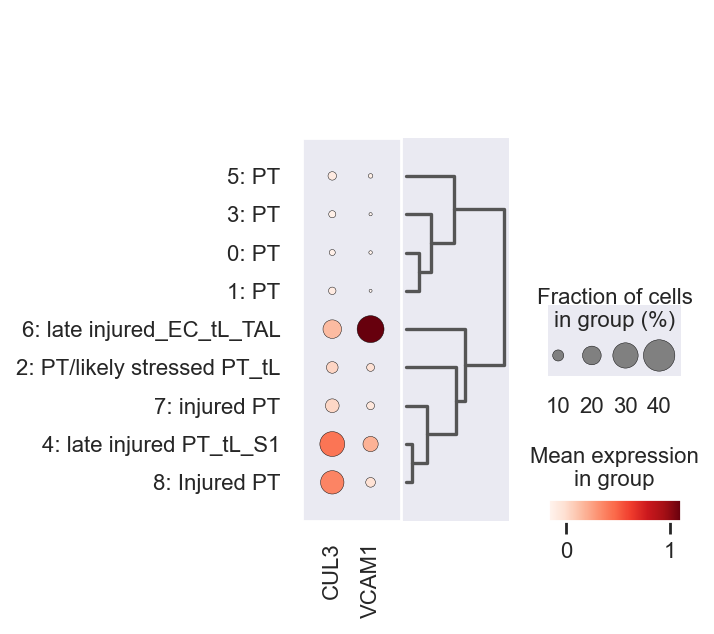

In [57]:
sc.pl.dotplot(tmp_copy_adata, genelist, groupby='leiden0.9', dendrogram=True)

In [58]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined,barcode,CUL3_Status,VCAM1_Status,g_Status
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29815-0,g_pos,g_pos,g_pos
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29816-0,g_neg,g_pos,g_pos
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29817-0,g_pos,g_pos,g_pos
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29818-0,g_neg,g_neg,g_neg
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29820-0,g_neg,g_pos,g_pos


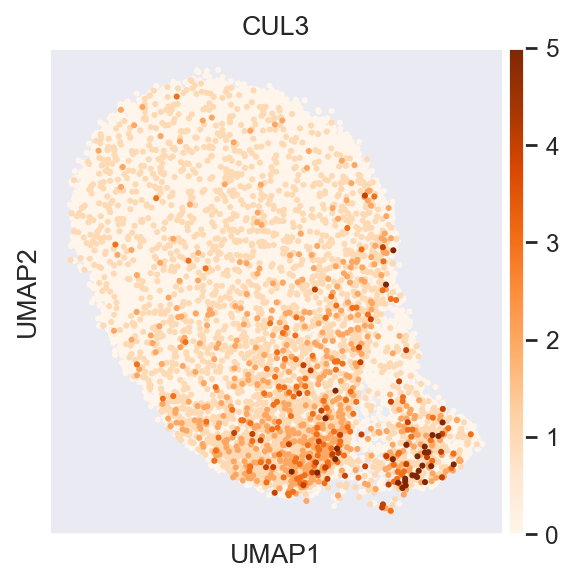

In [60]:
#sc.set_figure_params(fontsize=14)
## Plot marker genes
plt.rcParams.update({'font.size': 18})
sc.pl.embedding(adata, basis='umap', color=['CUL3'], color_map='Oranges', size=30, ncols=3, show=False, vmax=5)
plt.savefig(resulthome+'Human_ckd_select_genes_UMAPs.pdf', bbox_inches='tight')

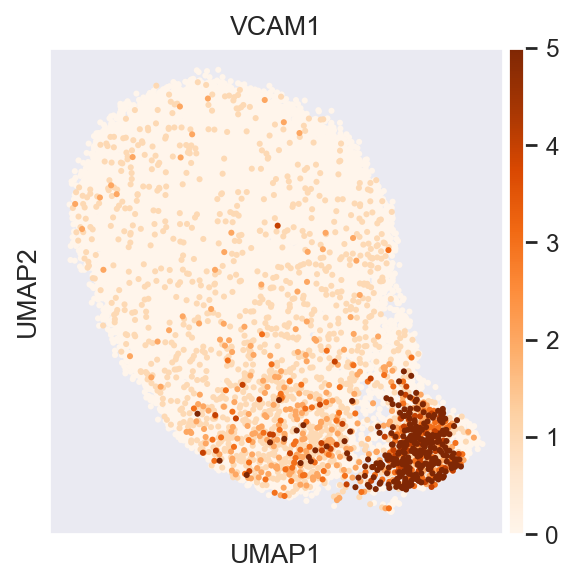

In [61]:
#sc.set_figure_params(fontsize=14)
## Plot marker genes
plt.rcParams.update({'font.size': 18})
sc.pl.embedding(adata, basis='umap', color=['VCAM1'], color_map='Oranges', size=30, ncols=3, show=False, vmax=5)
plt.savefig(resulthome+'Human_ckd_select_genes_UMAPs.pdf', bbox_inches='tight')

In [62]:
adata

AnnData object with n_obs × n_vars = 33701 × 15429
    obs: 'Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', 'Core.Matrisome.Expression.Score', 'Patient ID', 'mypatients', 'myconditions', 'sex', 'Sex', 'Age [years]', 'Serum creatinine [mg/dL]', 'eGFR (mL/min/1.73m2)', 'Interstitial fibrosis [%]', 'Tubular atrophy [%]', 'ischemia time in minutes', 'diabetes', 'Hyper-tension', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'mycelltypes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sizeFactor', 'ident', 'leiden1.1', 'batch', 'leiden0.1', 'leiden0.3', 'leiden0.5', 'leiden0.7', 'leiden0.9', 'leiden1.3', 'leiden1.5', 'leiden1.7', 'myconditions_combined', 'barcode', 'CUL3_Status', 'VCAM1_Status', 'g_Status'
    var: 'gene_ids-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0'
    uns: 'rank_genes_groups0.1', 'rank_genes_groups0.3', 'rank_genes_groups0.5', 'rank_genes_groups0.7', 'rank_genes_g

In [63]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined,barcode,CUL3_Status,VCAM1_Status,g_Status
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29815-0,g_pos,g_pos,g_pos
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29816-0,g_neg,g_pos,g_pos
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29817-0,g_pos,g_pos,g_pos
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29818-0,g_neg,g_neg,g_neg
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29820-0,g_neg,g_pos,g_pos


In [64]:
sc.tl.rank_genes_groups(tmp_copy_adata, 'CUL3_Status', groups=['g_pos'], reference='g_neg',\
                        method='wilcoxon', use_raw=False)

/Users/shayat/opt/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


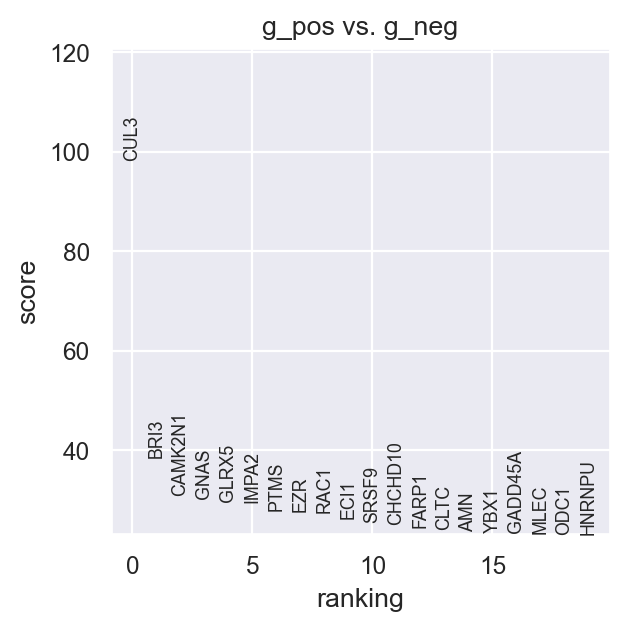

In [65]:
sc.pl.rank_genes_groups(tmp_copy_adata, groups=['g_pos'], n_genes=20, use_raw=False)

/Users/shayat/opt/anaconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


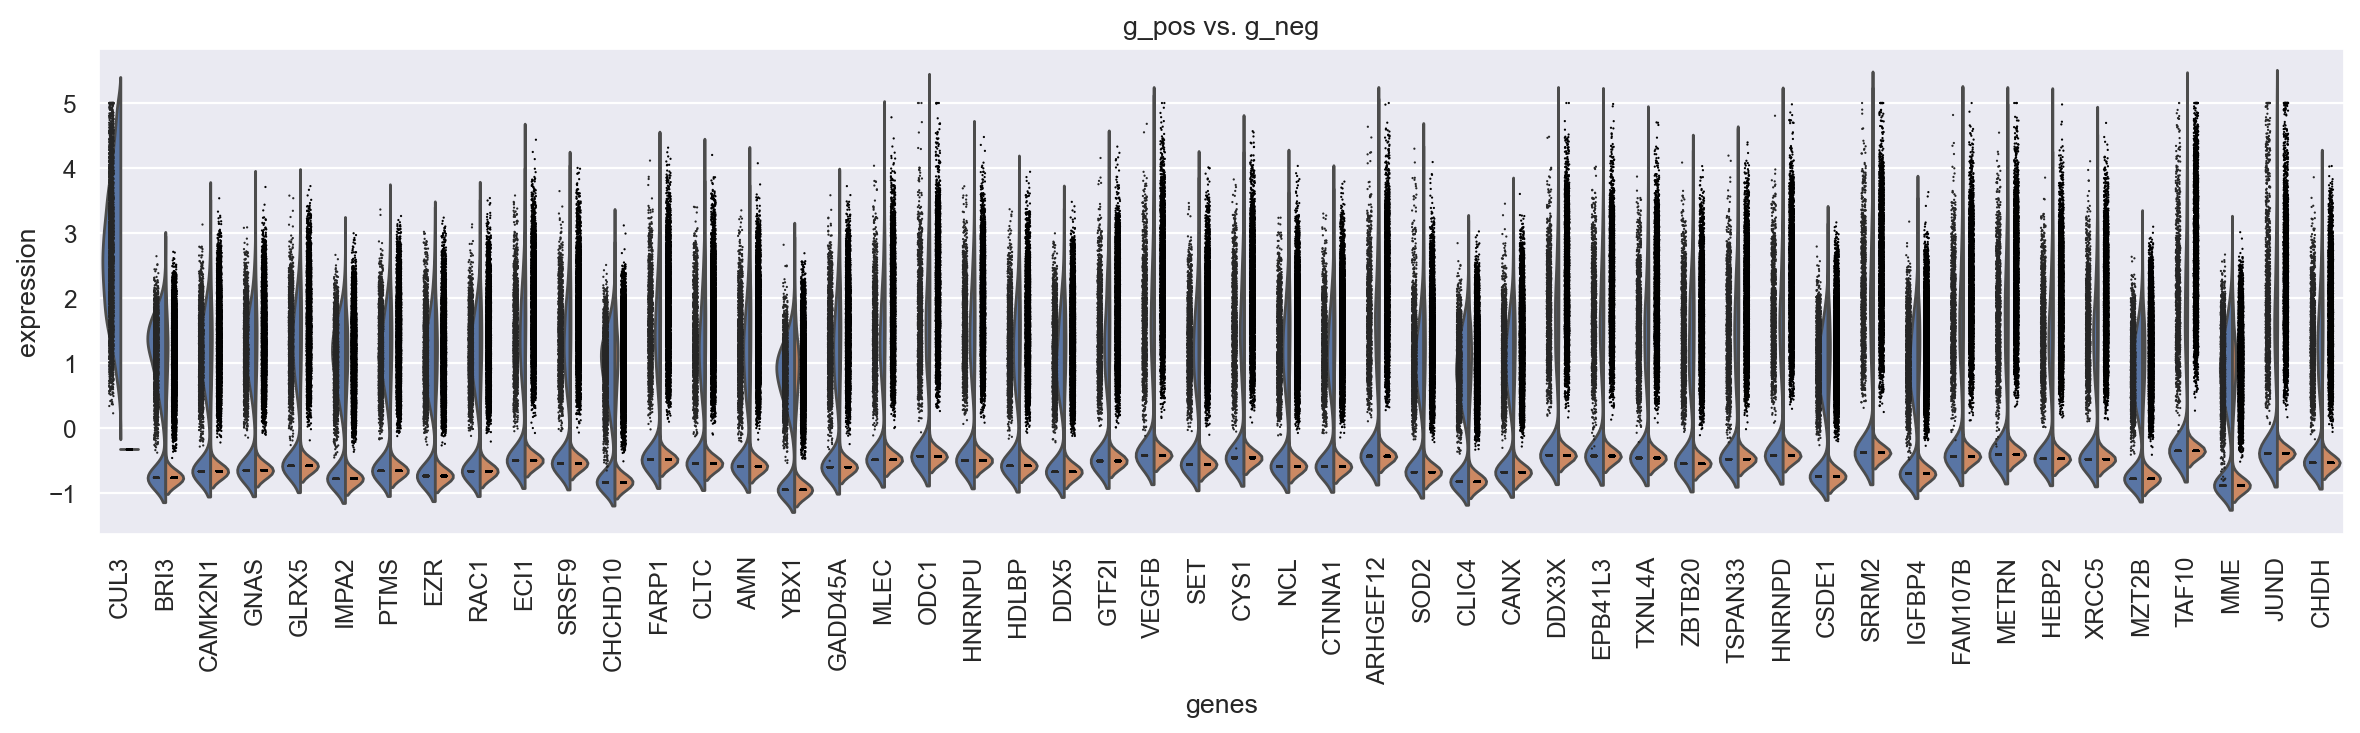

In [66]:
plt.figure(figsize=(18, 4))

sc.pl.rank_genes_groups_violin(tmp_copy_adata, groups='g_pos', n_genes=50, use_raw=False)

In [55]:
filename

'pt_ipt_populations.h5ad'

In [56]:
adata.obs.head()

,Annotation.Level.1,Annotation.Level.2,Annotation.Level.3,Core.Matrisome.Expression.Score,Patient ID,mypatients,myconditions,sex,Sex,Age [years],...,leiden0.7,leiden0.9,leiden1.3,leiden1.5,leiden1.7,myconditions_combined,barcode,CUL3_Status,VCAM1_Status,g_Status
29815-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.019521,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29815-0,g_pos,g_pos,g_pos
29816-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.097730,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29816-0,g_neg,g_pos,g_pos
29817-0,Epithelial,Injured Tubule,Injured Proximal tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,5,6: late injured_EC_tL_TAL,10,10,10,healthy,29817-0,g_pos,g_pos,g_pos
29818-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29818-0,g_neg,g_neg,g_neg
29820-0,Epithelial,Proximal Tubule,Proximal Tubule,0.000000,CDm1,CDm1,healthy,female,F,70,...,3,2: PT/likely stressed PT_tL,3,5,6,healthy,29820-0,g_neg,g_pos,g_pos


In [57]:
#adata.write(resulthome + filename[:-5] + '_cul3_for_DE.h5ad')

In [58]:
#resulthome+filename[:-5] + '_cul3_for_DE.h5ad'

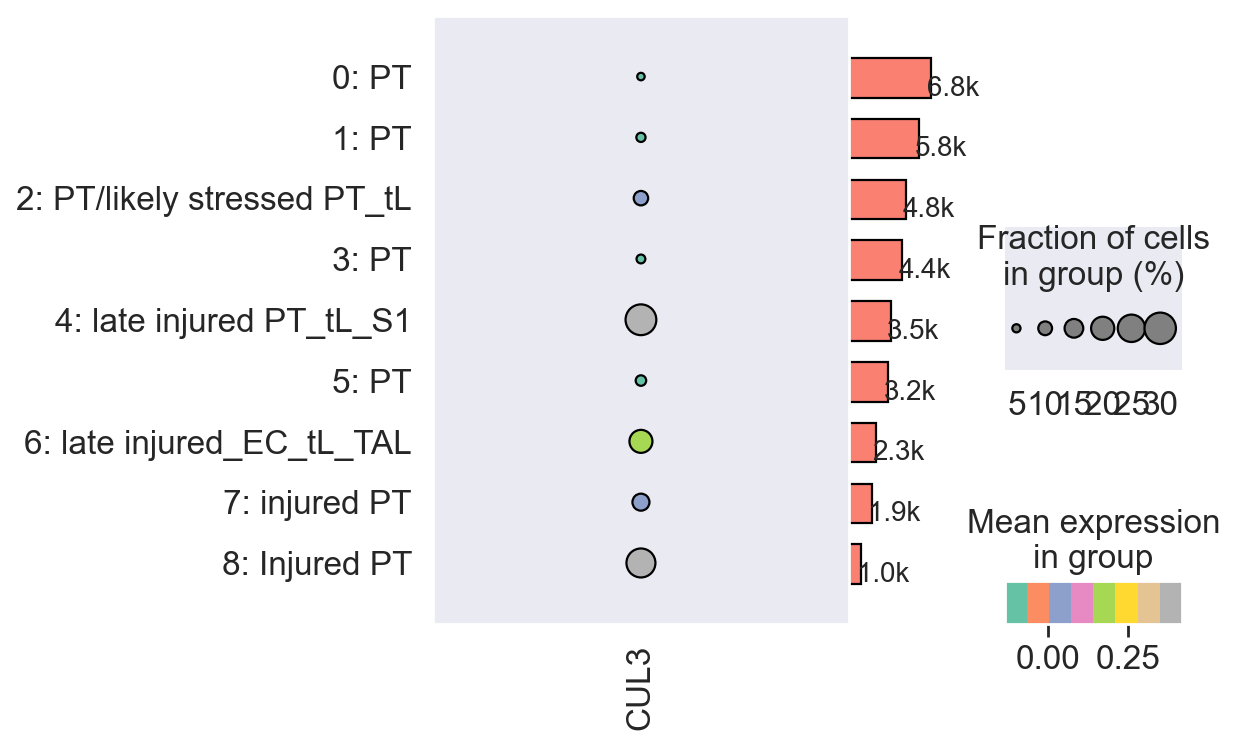

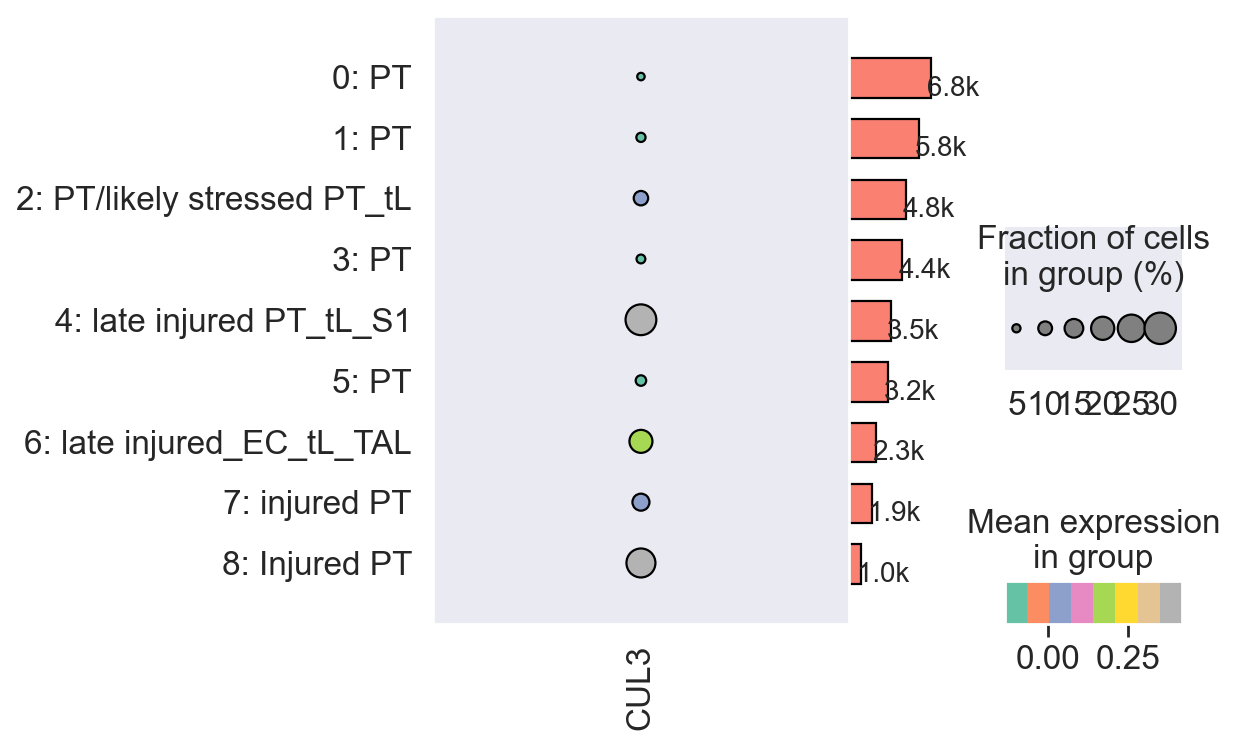

In [59]:
#fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 18})

dp =sc.pl.dotplot(tmp_copy_adata, ['CUL3'], groupby="leiden0.9", dendrogram=False,\
                  figsize=(6, 5), return_fig=True)

dp.add_totals().style(dot_edge_color='black', dot_edge_lw=1., cmap="Set2").show()

dp.savefig(resulthome+'Human_ckd_select_genes_dots.pdf', bbox_inches='tight')

In [60]:
adata

AnnData object with n_obs × n_vars = 33701 × 15429
    obs: 'Annotation.Level.1', 'Annotation.Level.2', 'Annotation.Level.3', 'Core.Matrisome.Expression.Score', 'Patient ID', 'mypatients', 'myconditions', 'sex', 'Sex', 'Age [years]', 'Serum creatinine [mg/dL]', 'eGFR (mL/min/1.73m2)', 'Interstitial fibrosis [%]', 'Tubular atrophy [%]', 'ischemia time in minutes', 'diabetes', 'Hyper-tension', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'mycelltypes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sizeFactor', 'ident', 'leiden1.1', 'batch', 'leiden0.1', 'leiden0.3', 'leiden0.5', 'leiden0.7', 'leiden0.9', 'leiden1.3', 'leiden1.5', 'leiden1.7', 'myconditions_combined', 'barcode', 'CUL3_Status', 'VCAM1_Status', 'g_Status'
    var: 'gene_ids-0', 'mt-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0'
    uns: 'rank_genes_groups0.1', 'rank_genes_groups0.3', 'rank_genes_groups0.5', 'rank_genes_groups0.7', 'rank_genes_g

In [73]:
pd.crosstab(adata.obs["CUL3_Status"], adata.obs["myconditions_combined"])

myconditions_combined,ckd,healthy
CUL3_Status,,
g_neg,3220,26871
g_pos,1243,2367


In [74]:
####

In [64]:
mykey     = "myconditions_combined"
cell_type = "leiden0.9"
#cell_type = "cell_type_original"

In [65]:
count_df = pd.crosstab(adata.obs[mykey], adata.obs[cell_type])
mycount_adata = anndata.AnnData(X=count_df)
mycount_adata.obs[mykey] = mycount_adata.obs.index

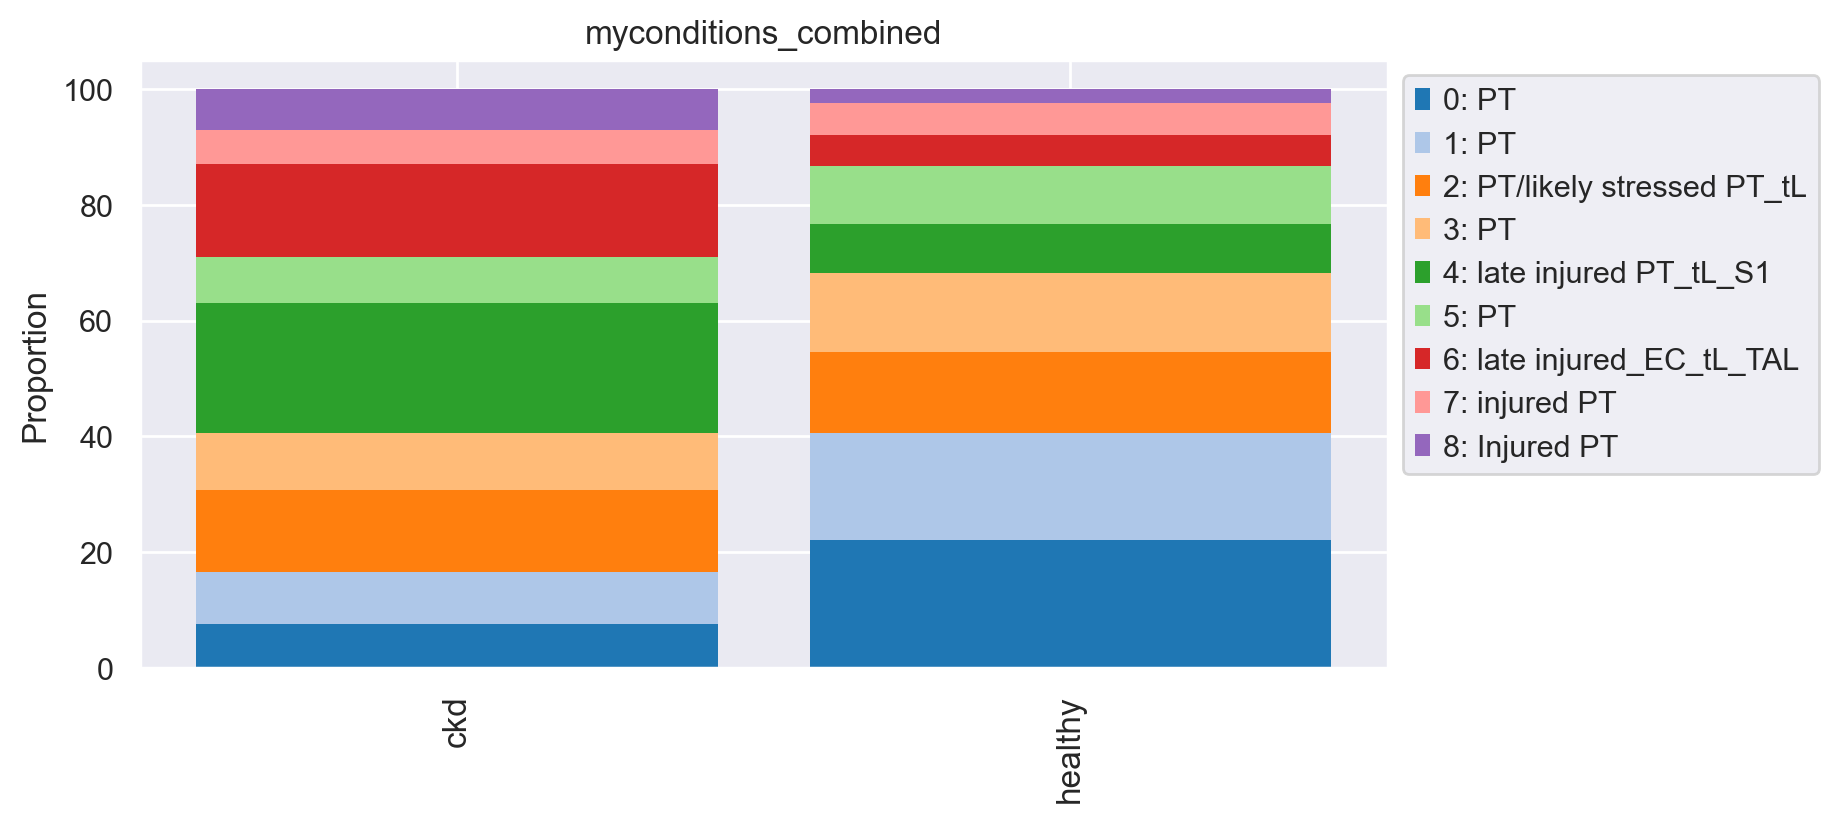

In [66]:
##visualization
viz.stacked_barplot(mycount_adata, feature_name=mykey, figsize=(8,4))
plt.xticks(fontsize=12, rotation=90)
plt.show()

In [67]:
res = pd.DataFrame(columns=adata.var_names, index=adata.obs['leiden0.9'].cat.categories)                                                                                                 

for clust in adata.obs['leiden0.9'].cat.categories: 
    res.loc[clust] = adata[adata.obs['leiden0.9'].isin([clust]),:].X.mean(0)

In [68]:
res

,WASH7P,MIR1302-2HG,AL627309.1,FO538757.1,AP006222.1,RPL23AP24,AL732372.2,AL669831.3,MTND1P23,MTND2P28,...,UTY,PSMA6P1,TMSB4Y,NLGN4Y,FAM224B,FAM224A,TTTY14,TXLNGY,KDM5D,EIF1AY
0: PT,0.001178,0.001178,0.000883,0.002503,0.008097,0.001619,0.00103,0.001767,4.497303,0.911833,...,0.001767,0.002208,0.008097,0.001767,0.011335,0.011335,0.048874,0.010452,0.002503,0.126158
1: PT,0.001034,0.001724,0.000345,0.002068,0.007411,0.002758,0.001034,0.002068,3.015016,0.643059,...,0.002585,0.002413,0.007067,0.002241,0.014478,0.014478,0.062737,0.01172,0.004309,0.14857
2: PT/likely stressed PT_tL,0.001051,0.001892,0.001051,0.004414,0.013871,0.004834,0.001681,0.004203,5.385658,1.115579,...,0.004203,0.002732,0.009037,0.004414,0.013241,0.013241,0.077764,0.015132,0.006095,0.174022
3: PT,0.001585,0.001132,0.001132,0.002943,0.011546,0.00249,0.001585,0.002943,1.769068,0.436947,...,0.001585,0.002264,0.011546,0.002943,0.016753,0.016753,0.077202,0.021281,0.004075,0.220059
4: late injured PT_tL_S1,0.003152,0.003725,0.002292,0.011748,0.031805,0.012894,0.004585,0.007163,3.834659,0.878216,...,0.010602,0.006017,0.015759,0.00659,0.014327,0.014327,0.102866,0.035817,0.011175,0.255015
5: PT,0.001848,0.000616,0.0,0.004313,0.012631,0.002773,0.000924,0.003389,3.576708,0.913736,...,0.004005,0.001848,0.00955,0.005545,0.018484,0.018484,0.057609,0.018176,0.003697,0.167899
6: late injured_EC_tL_TAL,0.006582,0.003949,0.007021,0.010092,0.044318,0.005704,0.029399,0.034664,2.562089,0.704256,...,0.060992,0.012286,0.015796,0.021939,0.024133,0.024133,0.067135,0.136025,0.048706,0.195262
7: injured PT,0.003694,0.005277,0.001055,0.006332,0.017942,0.004749,0.002111,0.010554,3.142478,0.67388,...,0.006332,0.004749,0.022691,0.004749,0.029551,0.029551,0.153562,0.036412,0.006332,0.373616
8: Injured PT,0.003918,0.000979,0.003918,0.008815,0.028404,0.011753,0.003918,0.002938,1.830555,0.577865,...,0.006856,0.005877,0.018609,0.006856,0.020568,0.020568,0.1381,0.031342,0.015671,0.322233
